# HyWindSea SANTANDER - Build RBF

PCA of the SWAN wave fields, a K-Fold sweep to decide how many cases the RBF
actually needs, and then the RBF itself: wind PCs in, wave PCs out.

**Reads** `inputs/swanruns_pos0m_times500.nc`, `outputs/SANTANDER/pca/pca_era5.pkl`
**Writes** `outputs/SANTANDER/pca/pca_<var>_pos0m.pkl`, `outputs/SANTANDER/rbf/rbf_<var>_pos0m.pkl`, `outputs/SANTANDER/times/rbf_{train,test}_pos0m.txt`

In [1]:
import os

import numpy as np
import pandas as pd
import xarray as xr
from bluemath_tk.core.io import load_model
from bluemath_tk.datamining.mda import MDA
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.interpolation.rbf import RBF, KFold_cross_validation_RBF

from utils.operations import (
    angular_difference,
    direction_to_uv,
    make_pca_metric,
    summarize_kfold,
    uv_to_direction,
)
from utils.plotting import plot_kfold_curves, set_paper_style

set_paper_style()

In [2]:
SITE = "SANTANDER"
TIDE = "pos0m"

N_CASES = 500                     # SWAN runs available
N_TEST = 50                       # held out from everything, the K-Fold included

# Explained variance kept per wave variable. Tm02 and Dir are noisier: at 0.99
# they would need far more components than the wind can actually predict.
VARS = {
    "Hsig_rescaled": 0.99,
    "Tm02": 0.90,
    "Dir": 0.90,
}

# Angles cannot go into a PCA as plain numbers: 359 deg and 1 deg are 358 apart
# arithmetically but 2 apart physically. These are decomposed into sine and
# cosine first and recombined afterwards.
DIRECTIONAL_VARS = {"Dir"}

UNITS = {"Hsig_rescaled": "m", "Tm02": "s", "Dir": "deg"}

# Training-set sizes to try in the K-Fold sweep.
N_CASES_LIST = [20, 50, 100, 200, 300, 450]
N_SPLITS = 5

SWAN_FILE = f"inputs/swanruns_{TIDE}_times{N_CASES}.nc"
PCA_WIND_FILE = f"outputs/{SITE}/pca/pca_era5.pkl"

PCA_DIR = f"outputs/{SITE}/pca"
RBF_DIR = f"outputs/{SITE}/rbf"
TIMES_DIR = f"outputs/{SITE}/times"

for directory in (PCA_DIR, RBF_DIR, TIMES_DIR):
    os.makedirs(directory, exist_ok=True)

## Inputs

In [3]:
waves = xr.open_dataset(SWAN_FILE)
pca_wind = load_model(PCA_WIND_FILE)

# Only cases that exist in both the SWAN runs and the ERA5 PCA can be used.
times = pd.to_datetime(waves.time.values).intersection(pca_wind.pcs_df.index)

print(f"SWAN cases      : {waves.sizes['time']}")
print(f"ERA5 wind PCs   : {pca_wind.pca.n_components_} components, "
      f"{pca_wind.cumulative_explained_variance_ratio[-1]:.1%} of the variance")
print(f"Usable cases    : {len(times)}")
waves

SWAN cases      : 500
ERA5 wind PCs   : 11 components, 99.6% of the variance
Usable cases    : 500


<xarray.Dataset> Size: 558MB
Dimensions:        (lat: 182, lon: 219, time: 500)
Coordinates:
  * lon            (lon) float64 2kB -3.83 -3.83 -3.829 ... -3.722 -3.722 -3.721
  * lat            (lat) float64 1kB 43.39 43.39 43.39 ... 43.48 43.48 43.48
  * time           (time) datetime64[ns] 4kB 1984-10-04T09:00:00 ... 2016-02-...
    quantile       float64 8B ...
Data variables:
    Hsig_rescaled  (lat, lon, time) float32 80MB ...
    TPsmoo         (lat, lon, time) float64 159MB ...
    Tm02           (lat, lon, time) float64 159MB ...
    Dir            (lat, lon, time) float64 159MB ...
    depth          (lat, lon) float64 319kB ...

## PCA of the wave fields

One PCA per variable. Land cells are NaN at every time and are dropped
automatically — the `Using N out of M available variables` warning is that
happening, not a problem.

`MDA` and `RBF` handle circular variables through their `directional_variables`
argument, but `PCA` has no equivalent, so `Dir` is decomposed into sine and
cosine by hand before fitting.

In [4]:
pca_waves = {}

for var, n_components in VARS.items():
    if var in DIRECTIONAL_VARS:
        data, vars_to_stack = direction_to_uv(waves, var), [f"{var}_u", f"{var}_v"]
    else:
        data, vars_to_stack = waves[[var]], [var]

    pca = PCA(n_components=n_components)
    pca.fit_transform(
        data=data,
        vars_to_stack=vars_to_stack,
        coords_to_stack=["lat", "lon"],
        pca_dim_for_rows="time",
    )
    pca.save_model(f"{PCA_DIR}/pca_{var}_{TIDE}.pkl")
    pca_waves[var] = pca

    print(f"{var:15} {pca.pca.n_components_:3d} PCs for "
          f"{pca.cumulative_explained_variance_ratio[-1]:.1%}")

INFO:PCA:Setting self.num_workers to 1. Change it using self.set_num_processors_to_use method.
INFO:PCA:
        -------------------------------------------------------------------
        | Initializing PCA reduction model with the following parameters:
        |    - n_components: 0.99
        |    - is_incremental: False
        | For more information, please refer to the documentation.
        -------------------------------------------------------------------
        
INFO:PCA:Explained variance ratio: 0.99
INFO:PCA:Using PCA
INFO:PCA:Adding windows in PCA dimension for rows
INFO:PCA:Generating stacked data matrix
INFO:PCA:Generating data matrix with variables to stack: ['Hsig_rescaled'] and coordinates to stack: ['lat', 'lon']
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
INFO:PCA:Data matrix generated successfully with shape: (500, 11363)
INFO:PCA:Standarizing data matrix
INFO:PCA:Data preprocessed successfully
INFO:PCA:Fi

Hsig_rescaled    45 PCs for 99.0%


If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
INFO:PCA:Data matrix generated successfully with shape: (500, 11363)
INFO:PCA:Standarizing data matrix
INFO:PCA:Data preprocessed successfully
INFO:PCA:Fitting PCA model
INFO:PCA:PCA model fitted successfully
INFO:PCA:Saving model to outputs/SANTANDER/pca/pca_Tm02_pos0m.pkl


Tm02             26 PCs for 90.1%


INFO:PCA:Setting self.num_workers to 1. Change it using self.set_num_processors_to_use method.
INFO:PCA:
        -------------------------------------------------------------------
        | Initializing PCA reduction model with the following parameters:
        |    - n_components: 0.9
        |    - is_incremental: False
        | For more information, please refer to the documentation.
        -------------------------------------------------------------------
        
INFO:PCA:Explained variance ratio: 0.9
INFO:PCA:Using PCA
INFO:PCA:Adding windows in PCA dimension for rows
INFO:PCA:Generating stacked data matrix
INFO:PCA:Generating data matrix with variables to stack: ['Dir_u', 'Dir_v'] and coordinates to stack: ['lat', 'lon']
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
INFO:PCA:Data matrix generated successfully with sha

Dir              18 PCs for 90.2%


## Order the cases and reserve a test set

MDA orders the cases by maximum dissimilarity in wind-PC space. The tail becomes
the test set: those are the cases MDA considered most redundant, so they are the
fair test of whether the interpolation generalises.

Everything before the tail is the **pool**. How much of that pool actually gets
used is decided further down, after the K-Fold — not here.

In [5]:
mda = MDA(num_centers=len(times))

mda.fit(
    data=pca_wind.pcs_df.loc[times],
    directional_variables=[],
)

ordered = pca_wind.pcs_df.loc[times].iloc[mda.centroid_real_indices].index
pool = ordered[:-N_TEST]
test_times = ordered[-N_TEST:]

np.savetxt(f"{TIMES_DIR}/rbf_test_{TIDE}.txt",
           test_times.values.astype("datetime64[s]").astype(str), fmt="%s")

print(f"pool: {len(pool)}   test: {len(test_times)}")

pool: 450   test: 50


## How many cases does the RBF need?

K-Fold cross-validation over the first N cases of the pool, for several values of
N. Each split trains on 80 % and predicts the rest, and the error is measured on
the reconstructed field rather than on the PCs.

Only the RBF error moves here: both sides of the comparison go through the same
PCA, so the truncation error cancels and what is left is what changes with the
size of the training set.

In [6]:
curves = {}

for var, pca in pca_waves.items():
    metric = make_pca_metric(pca, var, directional=var in DIRECTIONAL_VARS)
    rows = {}

    for n_cases in N_CASES_LIST:
        cases = pool[:n_cases]
        results = KFold_cross_validation_RBF(
            subset_data=pca_wind.pcs_df.loc[cases],
            target_data=pca.pcs_df.loc[cases],
            normalize_target_data=True,
            rbf_model=RBF(kernel="linear"),
            num_workers=4,
            n_splits=N_SPLITS,
            metric=metric,
        )
        mean, std = summarize_kfold(results, "rmse")
        rows[n_cases] = {"mean": mean, "std": std}
        print(f"{var:15} n={n_cases:3d}   RMSE = {mean:.4f} +- {std:.4f} {UNITS[var]}")

    curves[var] = pd.DataFrame(rows).T
    print()

INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model


Hsig_rescaled   n= 20   RMSE = 0.1585 +- 0.0420 m


INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model


Hsig_rescaled   n= 50   RMSE = 0.0877 +- 0.0097 m


INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model


...

Dir             n=200   RMSE = 36.4169 +- 3.2248 deg


INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model


Dir             n=300   RMSE = 37.4895 +- 2.2717 deg


INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model


Dir             n=450   RMSE = 36.1969 +- 3.1259 deg



## Choose the training-set size

Read the table above for the **elbow**, not the minimum: more cases almost always
help a little, and the question is where they stop paying for themselves. Where
the ±1 std bands of two sizes overlap, those two are not distinguishable.

`N_TRAIN` is set here, after the numbers are on screen — that is the whole point
of running the sweep first. The print below says what the choice costs against
the best size tried, per variable.

In [7]:
N_TRAIN = 300

train_times = pool[:N_TRAIN]

np.savetxt(f"{TIMES_DIR}/rbf_train_{TIDE}.txt",
           train_times.values.astype("datetime64[s]").astype(str), fmt="%s")

for var, curve in curves.items():
    best = curve["mean"].min()
    if N_TRAIN in curve.index:
        here = curve.loc[N_TRAIN, "mean"]
        print(f"{var:15} RMSE at {N_TRAIN} = {here:.4f} {UNITS[var]:4} "
              f"({100 * (here / best - 1):+.1f}% vs the best size tried)")
    else:
        print(f"{var:15} {N_TRAIN} not in N_CASES_LIST, no K-Fold estimate")

print(f"\ntrain: {len(train_times)}   test: {len(test_times)}")

Hsig_rescaled   RMSE at 300 = 0.0533 m    (+2.6% vs the best size tried)
Tm02            RMSE at 300 = 0.1657 s    (+4.5% vs the best size tried)
Dir             RMSE at 300 = 37.4895 deg  (+3.6% vs the best size tried)

train: 300   test: 50


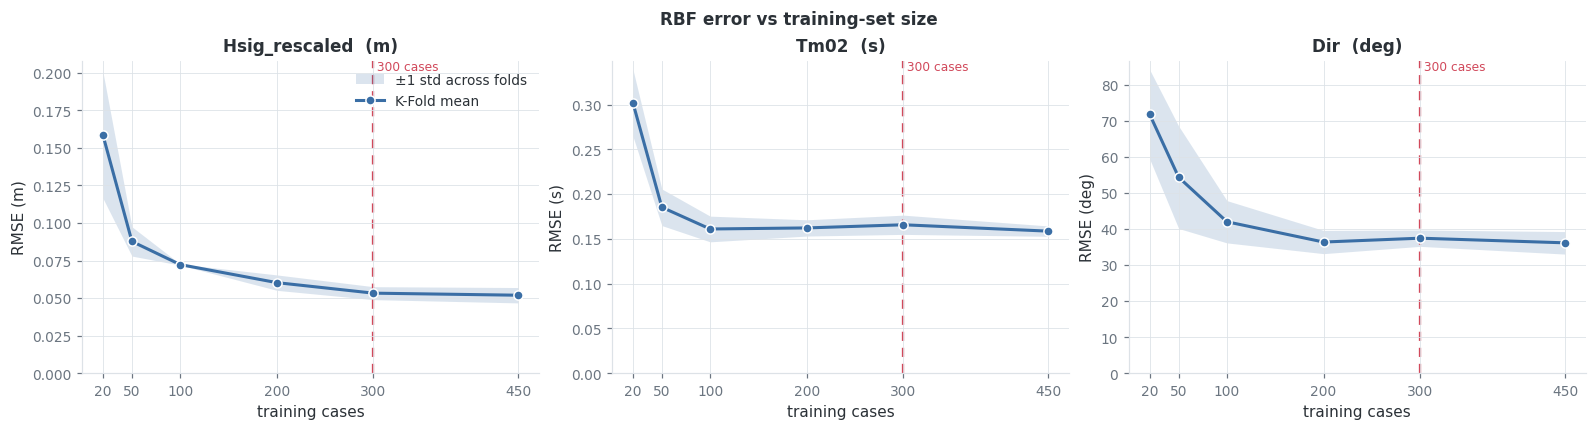

In [8]:
plot_kfold_curves(curves, units=UNITS, chosen=N_TRAIN);

## RBF

In [9]:
subset_train = pca_wind.pcs_df.loc[train_times]
subset_test = pca_wind.pcs_df.loc[test_times]

rbfs = {}

for var, pca in pca_waves.items():
    rbf = RBF(kernel="linear")
    rbf.fit(
        subset_data=subset_train,
        target_data=pca.pcs_df.loc[train_times],
        normalize_target_data=True,
        num_workers=4,
        iteratively_update_sigma=True,
    )
    rbf.save_model(f"{RBF_DIR}/rbf_{var}_{TIDE}.pkl")
    rbfs[var] = rbf

    print(f"{var:15} {subset_train.shape[1]} wind PCs -> "
          f"{pca.pcs_df.shape[1]} wave PCs")

Hsig_rescaled   11 wind PCs -> 45 wave PCs
Tm02            11 wind PCs -> 26 wave PCs
Dir             11 wind PCs -> 18 wave PCs


## Check against the held-out cases

The PCs are only an intermediate step, so the error is measured where it means
something: the predicted PCs are pushed back through `inverse_transform` to
rebuild the wave field, and compared with what SWAN produced.

In [10]:
scores = []

for var, rbf in rbfs.items():
    pca = pca_waves[var]

    predicted_pcs = rbf.predict(subset_test)
    reconstructed = pca.inverse_transform(
        PCs=xr.DataArray(
            predicted_pcs.values,
            dims=("time", "n_component"),
            coords={"time": test_times,
                    "n_component": np.arange(predicted_pcs.shape[1])},
        ).to_dataset(name="PCs")
    )

    if var in DIRECTIONAL_VARS:
        predicted = uv_to_direction(reconstructed, var)
        truth = waves[var].sel(time=test_times).transpose(*predicted.dims)
        # Plain subtraction would score 359 deg against 1 deg as an error of 358.
        error = angular_difference(predicted, truth)
    else:
        predicted = reconstructed[var]
        truth = waves[var].sel(time=test_times).transpose(*predicted.dims)
        error = (predicted - truth).values

    valid = ~np.isnan(error)

    scores.append({
        "variable": var,
        "rmse": float(np.sqrt(np.nanmean(error[valid] ** 2))),
        "median_abs": float(np.nanmedian(np.abs(error[valid]))),
        "bias": float(np.nanmean(error[valid])),
    })

pd.DataFrame(scores).set_index("variable")

INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model


,rmse,median_abs,bias
variable,,,
Hsig_rescaled,0.045351,0.027842,-0.002285
Tm02,0.180593,0.076574,-0.008906
Dir,44.064555,13.565867,2.237837
